/Users/bigcolour/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/bigcolour/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           15     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.13881D+00    |proj g|=  2.40083D+01

At iterate    5    f=  2.25030D-01    |proj g|=  1.88372D-01

At iterate   10    f=  5.39838D-02    |proj g|=  4.69557D-01

At iterate   15    f=  2.66964D-02    |proj g|=  1.62924D-02

At iterate   20    f=  2.50818D-02    |proj g|=  8.51896D-03

At iterate   25    f=  2.46592D-02    |proj g|=  1.68401D-02

At iterate   30    f=  2.40736D-02    |proj g|=  1.22447D-02

At iterate   35    f=  2.39235D-02    |proj g|=  5.93127D-03

At iterate   40    f=  2.38558D-02    |proj g|=  3.32540D-03

At iterate   45    f=  2.35606D-02    |proj g|=  2.89902D-02

At iterate   50    f=  2.34766D-02    |proj g|=  9.81122D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/Users/bigcolour/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE: 1.504


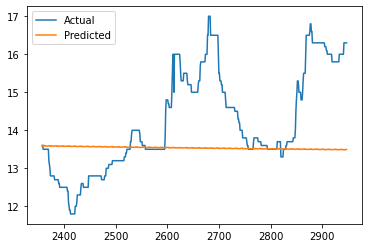

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Load data from Excel file 
df = pd.read_excel('/Users/bigcolour/Desktop/水产品价格预测/代码/new/4_预测/ARIMA/sarima_in.xlsx')


# Split data into training and test sets (80% training, 20% testing)
train_size = int(len(df) * 0.8)
train_data, test_data = df[:train_size], df[train_size:]

# Create SARIMA model
model = SARIMAX(train_data, order=(5, 0, 5), seasonal_order=(2, 1, 2, 12))

# Fit the model to the training data
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.forecast(steps=len(test_data))

# Print root mean squared error (RMSE) of predictions
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)
print('RMSE: %.3f' % rmse)

# Plot the actual values vs predicted values
plt.plot(test_data.index, test_data.values, label='Actual')
plt.plot(test_data.index, predictions, label='Predicted')
plt.legend()
plt.show()

